In [2]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from matplotlib_inline.backend_inline import set_matplotlib_formats


# Plotting
set_matplotlib_formats("retina")

plt.style.use(
    "https://raw.githubusercontent.com/"
    "ksingh1121/python-plot-style/main/physics.mplstyle"
)

In [3]:
# ============================================================
# CELL 1 — Initialize SLM + camera and load correction file
#
# Important:
#   wavefront_phase is ONLY a NumPy array at this stage.
#   It is NOT yet installed as an SLM correction.
# ============================================================

from pathlib import Path
import numpy as np

from slmsuite.hardware.slms.meadowlark import Meadowlark
from slmsuite.hardware.cameras.alliedvision import AlliedVision
from slmsuite.hardware.cameraslms import FourierSLM


# ------------------------------------------------------------
# Paths
# ------------------------------------------------------------

SDK_PATH = Path(
    r"C:\Program Files\Meadowlark Optics\Blink 1920 HDMI\SDK"
)

LUT_PATH = Path(
    r"C:\Users\admin\Desktop\Projects\SLM\SLM tests\Scripts\Experiment scripts"
    r"\LUT_locked_759nm_20260811_201109\759nm_KS_global_20260811.lut"
)

WAVEFRONT_PHASE_PATH = Path(
    r"C:\Users\admin\Desktop\Projects\SLM\SLM tests\Scripts\4f alignment scripts"
    r"\YDFC_wavefront_phase_processed_R2p80_50ms_dark.npy"
)


# ------------------------------------------------------------
# Initialize hardware ONCE in this notebook
# ------------------------------------------------------------

slm = Meadowlark(
    slm_number=1,
    sdk_path=str(SDK_PATH),
    lut_path=str(LUT_PATH),
    wav_um=0.7593,
    verbose=True,
)

cam = AlliedVision(
    serial="015C2",
    verbose=True,
)

fs = FourierSLM(cam, slm)


# ------------------------------------------------------------
# Load the measured correction from disk
#
# This only creates a NumPy array called wavefront_phase.
# It does NOT activate the correction.
# ------------------------------------------------------------

wavefront_phase = np.load(WAVEFRONT_PHASE_PATH)


# ------------------------------------------------------------
# Inspect our starting state
# ------------------------------------------------------------

print("SLM shape:", slm.shape)
print("Camera shape:", cam.shape)

print("\nLoaded correction:")
print(" shape :", wavefront_phase.shape)
print(" finite:", np.all(np.isfinite(wavefront_phase)))
print(" min   :", wavefront_phase.min())
print(" max   :", wavefront_phase.max())

print("\nCurrent slm.source keys:")
print(slm.source.keys())

print("\nGlobal default slm.phase_correct:")
print(slm.phase_correct)

c:\Users\admin\AppData\Local\Python\pythoncore-3.12-64\Lib\site-packages\slmsuite\holography\algorithms\_header.py:30: UserWarning: cupy is not installed; using numpy. Install cupy for faster GPU-based holography.
  warnings.warn(


Validating DPI awareness...success
Constructing Blink SDK...success
Loading LUT file...vmbpy initializing... success
Looking for cameras... success
vmbpy sn '015C2' initializing... success
SLM shape: (1200, 1920)
Camera shape: (3672, 5496)

Loaded correction:
 shape : (1200, 1920)
 finite: True
 min   : 0.0
 max   : 6.2831762207757835

Current slm.source keys:
dict_keys([])

Global default slm.phase_correct:
True


c:\Users\admin\AppData\Local\Python\pythoncore-3.12-64\Lib\site-packages\slmsuite\hardware\cameras\camera.py:444: UserWarning: '015C2' _get_image_hw() failed 5 times before quitting.
  warnings.warn(f"'{self.name}' _get_image_hw() failed {failures} times before quitting.")


Exposure [us]: 112.181
Image shape  : (3672, 5496)
Image min    : 0
Image max    : 255
Image mean   : 0.009330116892301154


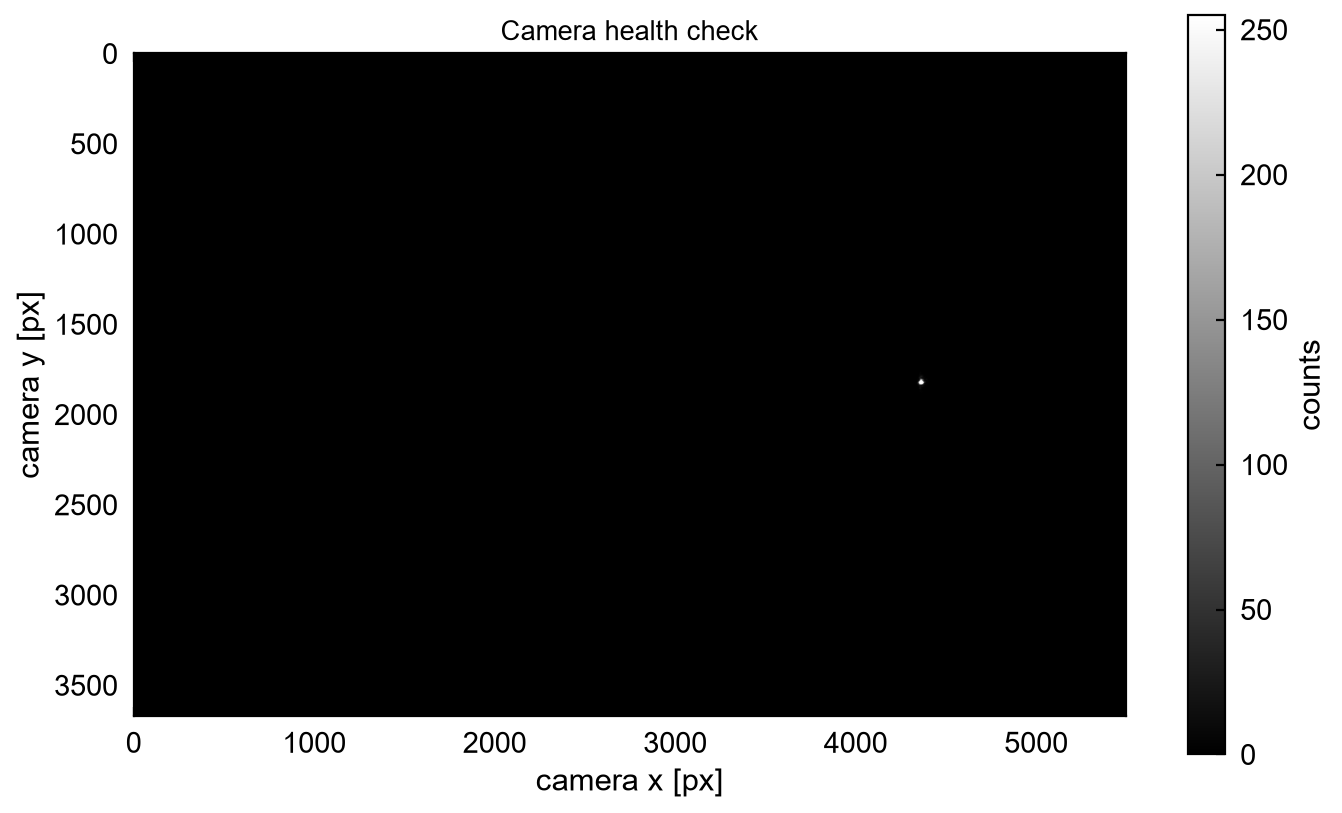

In [4]:
# ============================================================
# CELL 2 — Verify camera acquisition
# Do NOT reinitialize the camera
# ============================================================

cam.set_exposure(100e-6)   # 100 us

cam.flush()
img = cam.get_image()

print("Exposure [us]:", cam.exposure_s * 1e6)
print("Image shape  :", img.shape)
print("Image min    :", img.min())
print("Image max    :", img.max())
print("Image mean   :", img.mean())

plt.figure(figsize=(10, 6))
plt.imshow(
    img,
    cmap="gray",
    origin="upper"
)
plt.xlabel("camera x [px]")
plt.ylabel("camera y [px]")
plt.title("Camera health check")
plt.colorbar(label="counts")
plt.show()

In [5]:
# ============================================================
# CELL 3 — Create the 5×5 Fourier hologram
# and display it explicitly WITHOUT wavefront correction
# ============================================================

# Build the same Fourier-calibration array as before:
#
# 5×5 nominal grid
# pitch = 13 knm
# center = (128, 0) knm
#
# orientation_check=True inside fourier_grid_project()
# means two corner spots are omitted -> 23 visible spots.

holo_5x5 = fs.fourier_grid_project(
    array_shape=(5, 5),
    array_pitch=(13, 13),
    array_center=(128, 0),
    method="GS",
    maxiter=10,
)

# Extract the actual hologram phase as a NumPy array.
phase_5x5 = holo_5x5.get_phase()

print("phase_5x5 shape:", phase_5x5.shape)
print("phase_5x5 min  :", phase_5x5.min())
print("phase_5x5 max  :", phase_5x5.max())

print("\nCurrent slm.source keys:")
print(slm.source.keys())


# ------------------------------------------------------------
# NOW explicitly display the hologram with correction OFF
# ------------------------------------------------------------

slm.set_phase(
    phase_5x5,
    phase_correct=False,
    settle=True
)

print("\nDisplayed:")
print("5×5 hologram + NO wavefront correction")

c:\Users\admin\AppData\Local\Python\pythoncore-3.12-64\Lib\site-packages\slmsuite\holography\toolbox\__init__.py:258: UserWarning: CameraSLM must be passed as slm for conversion 'kxy' to 'ij'
  warnings.warn(


  0%|          | 0/10 [00:00<?, ?it/s]

phase_5x5 shape: (1200, 1920)
phase_5x5 min  : 2.3841858e-07
phase_5x5 max  : 6.2831783

Current slm.source keys:
dict_keys(['amplitude_center_pix', 'amplitude_radius', 'amplitude_extent', 'amplitude_extent_radius'])

Displayed:
5×5 hologram + NO wavefront correction


Actual exposure [us]: 497.181
ROI max             : 114
ROI mean            : 1.8609722222222222
Pixels >= 250       : 0
Pixels == 255       : 0


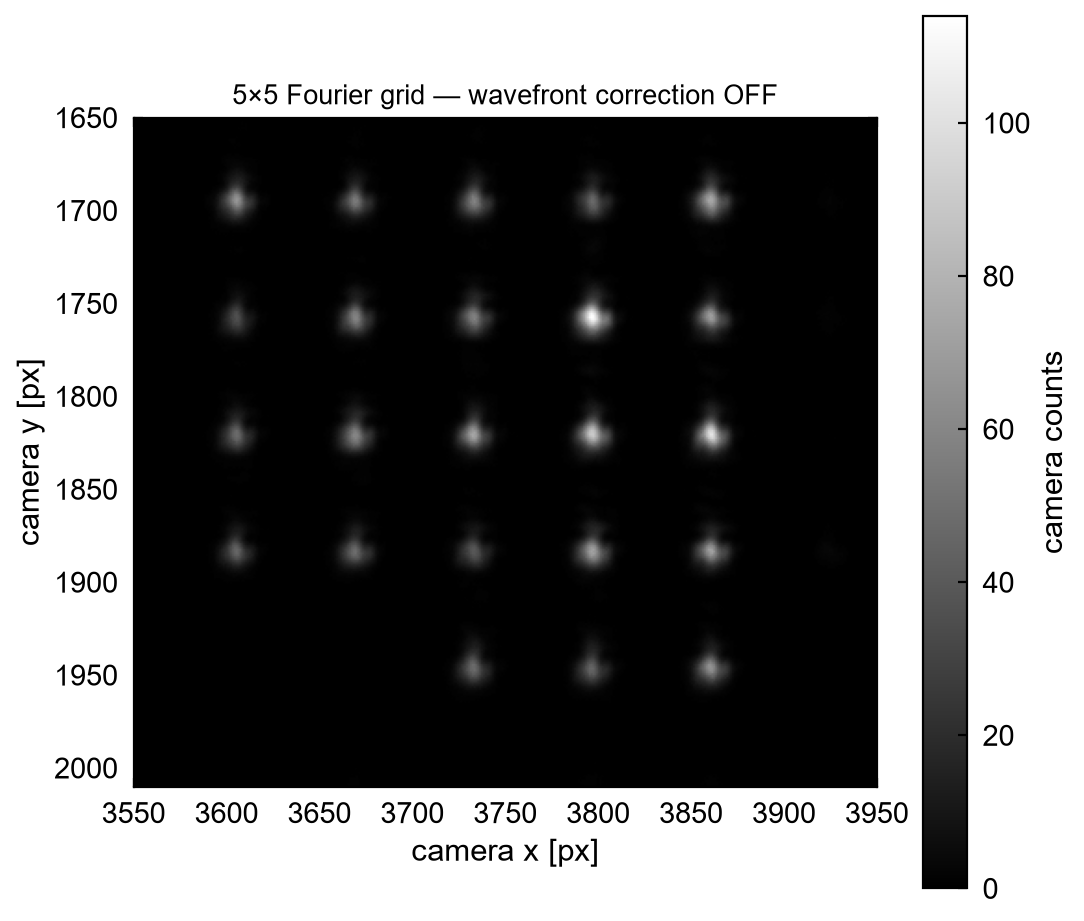

In [6]:
# ============================================================
# CELL 4 — Acquire the 5×5 with correction OFF
# ============================================================

cam.set_exposure(500e-6)   # ~500 us

cam.flush()
img_5x5_off = cam.get_image()

# Camera region containing the 5×5 array
x0, x1 = 3550, 3950
y0, y1 = 1650, 2010

roi_5x5_off = img_5x5_off[y0:y1, x0:x1]

print("Actual exposure [us]:", cam.exposure_s * 1e6)
print("ROI max             :", roi_5x5_off.max())
print("ROI mean            :", roi_5x5_off.mean())
print("Pixels >= 250       :", np.sum(roi_5x5_off >= 250))
print("Pixels == 255       :", np.sum(roi_5x5_off == 255))

plt.figure(figsize=(7, 6))

plt.imshow(
    roi_5x5_off,
    cmap="gray",
    origin="upper",
    extent=[x0, x1, y1, y0],
    vmin=0,
    vmax=roi_5x5_off.max()
)

plt.xlabel("camera x [px]")
plt.ylabel("camera y [px]")
plt.title("5×5 Fourier grid — wavefront correction OFF")
plt.colorbar(label="camera counts")

plt.tight_layout()
plt.show()

Current slm.source keys:
dict_keys(['amplitude_center_pix', 'amplitude_radius', 'amplitude_extent', 'amplitude_extent_radius', 'phase'])

Correction installed:
True

Actual exposure [us]: 497.181

CORRECTION OFF
ROI max : 114

CORRECTION ON
ROI max : 193

Pixels >= 250: 0
Pixels == 255: 0


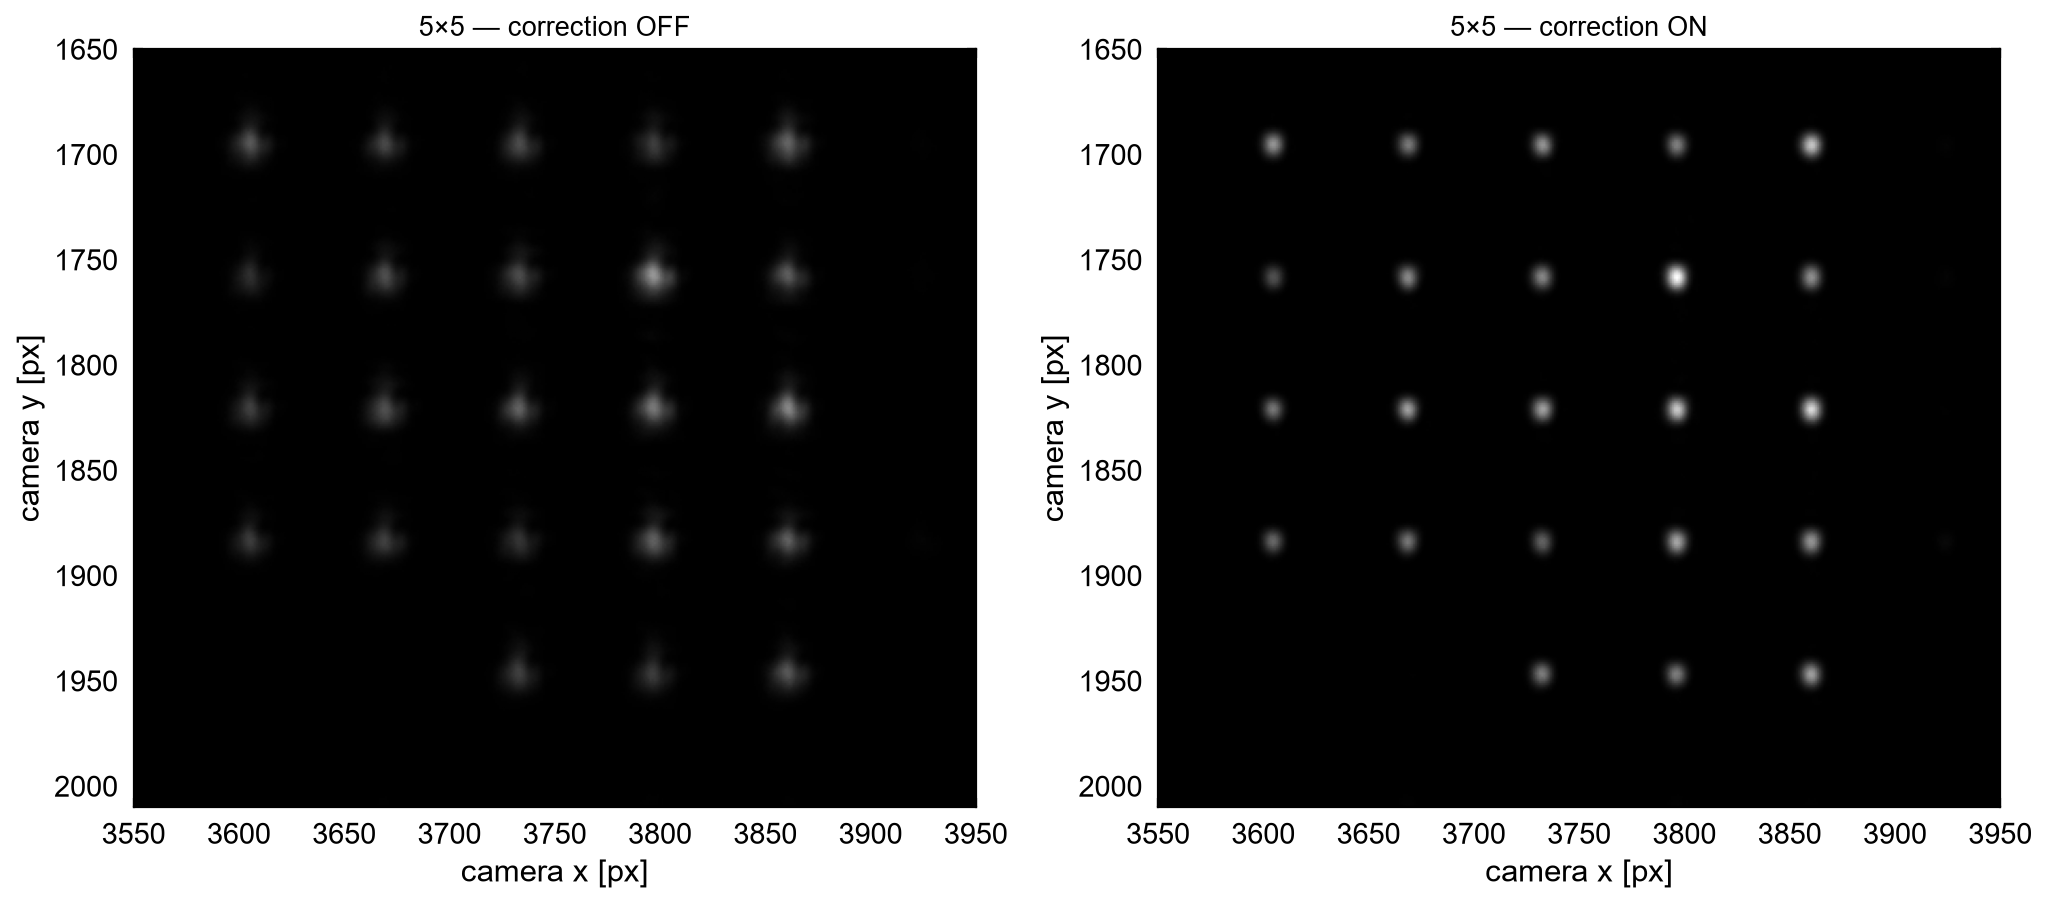

In [7]:
# ============================================================
# CELL 5 — INSTALL and INVOKE the wavefront correction
# ============================================================

# ------------------------------------------------------------
# 1. Install the correction
# ------------------------------------------------------------

slm.source["phase"] = wavefront_phase

print("Current slm.source keys:")
print(slm.source.keys())

print("\nCorrection installed:")
print("phase" in slm.source)


# ------------------------------------------------------------
# 2. Display the SAME 5×5 hologram,
#    now explicitly WITH wavefront correction
# ------------------------------------------------------------

slm.set_phase(
    phase_5x5,
    phase_correct=True,
    settle=True
)


# ------------------------------------------------------------
# 3. Acquire image at exactly the same exposure
# ------------------------------------------------------------

cam.flush()
img_5x5_on = cam.get_image()

roi_5x5_on = img_5x5_on[y0:y1, x0:x1]


print("\nActual exposure [us]:", cam.exposure_s * 1e6)

print("\nCORRECTION OFF")
print("ROI max :", roi_5x5_off.max())

print("\nCORRECTION ON")
print("ROI max :", roi_5x5_on.max())

print("\nPixels >= 250:", np.sum(roi_5x5_on >= 250))
print("Pixels == 255:", np.sum(roi_5x5_on == 255))


# ------------------------------------------------------------
# 4. Compare OFF and ON on the SAME grayscale scale
# ------------------------------------------------------------

vmax = max(
    roi_5x5_off.max(),
    roi_5x5_on.max()
)

fig, axs = plt.subplots(1, 2, figsize=(13, 6))

axs[0].imshow(
    roi_5x5_off,
    cmap="gray",
    origin="upper",
    extent=[x0, x1, y1, y0],
    vmin=0,
    vmax=vmax
)

axs[0].set_title("5×5 — correction OFF")

axs[1].imshow(
    roi_5x5_on,
    cmap="gray",
    origin="upper",
    extent=[x0, x1, y1, y0],
    vmin=0,
    vmax=vmax
)

axs[1].set_title("5×5 — correction ON")

for ax in axs:
    ax.set_xlabel("camera x [px]")
    ax.set_ylabel("camera y [px]")

plt.tight_layout()
plt.show()

Optical phase OFF range:
2.3841858e-07 6.2831783

Optical phase ON range:
3.370065162044966e-06 6.2831803401019535

Hardware display dtype:
uint8

Hardware grayscale OFF range:
0 255

Hardware grayscale ON range:
0 255

Number of hardware pixels changed:
2294875
Fraction of SLM pixels changed: 0.9960394965277778


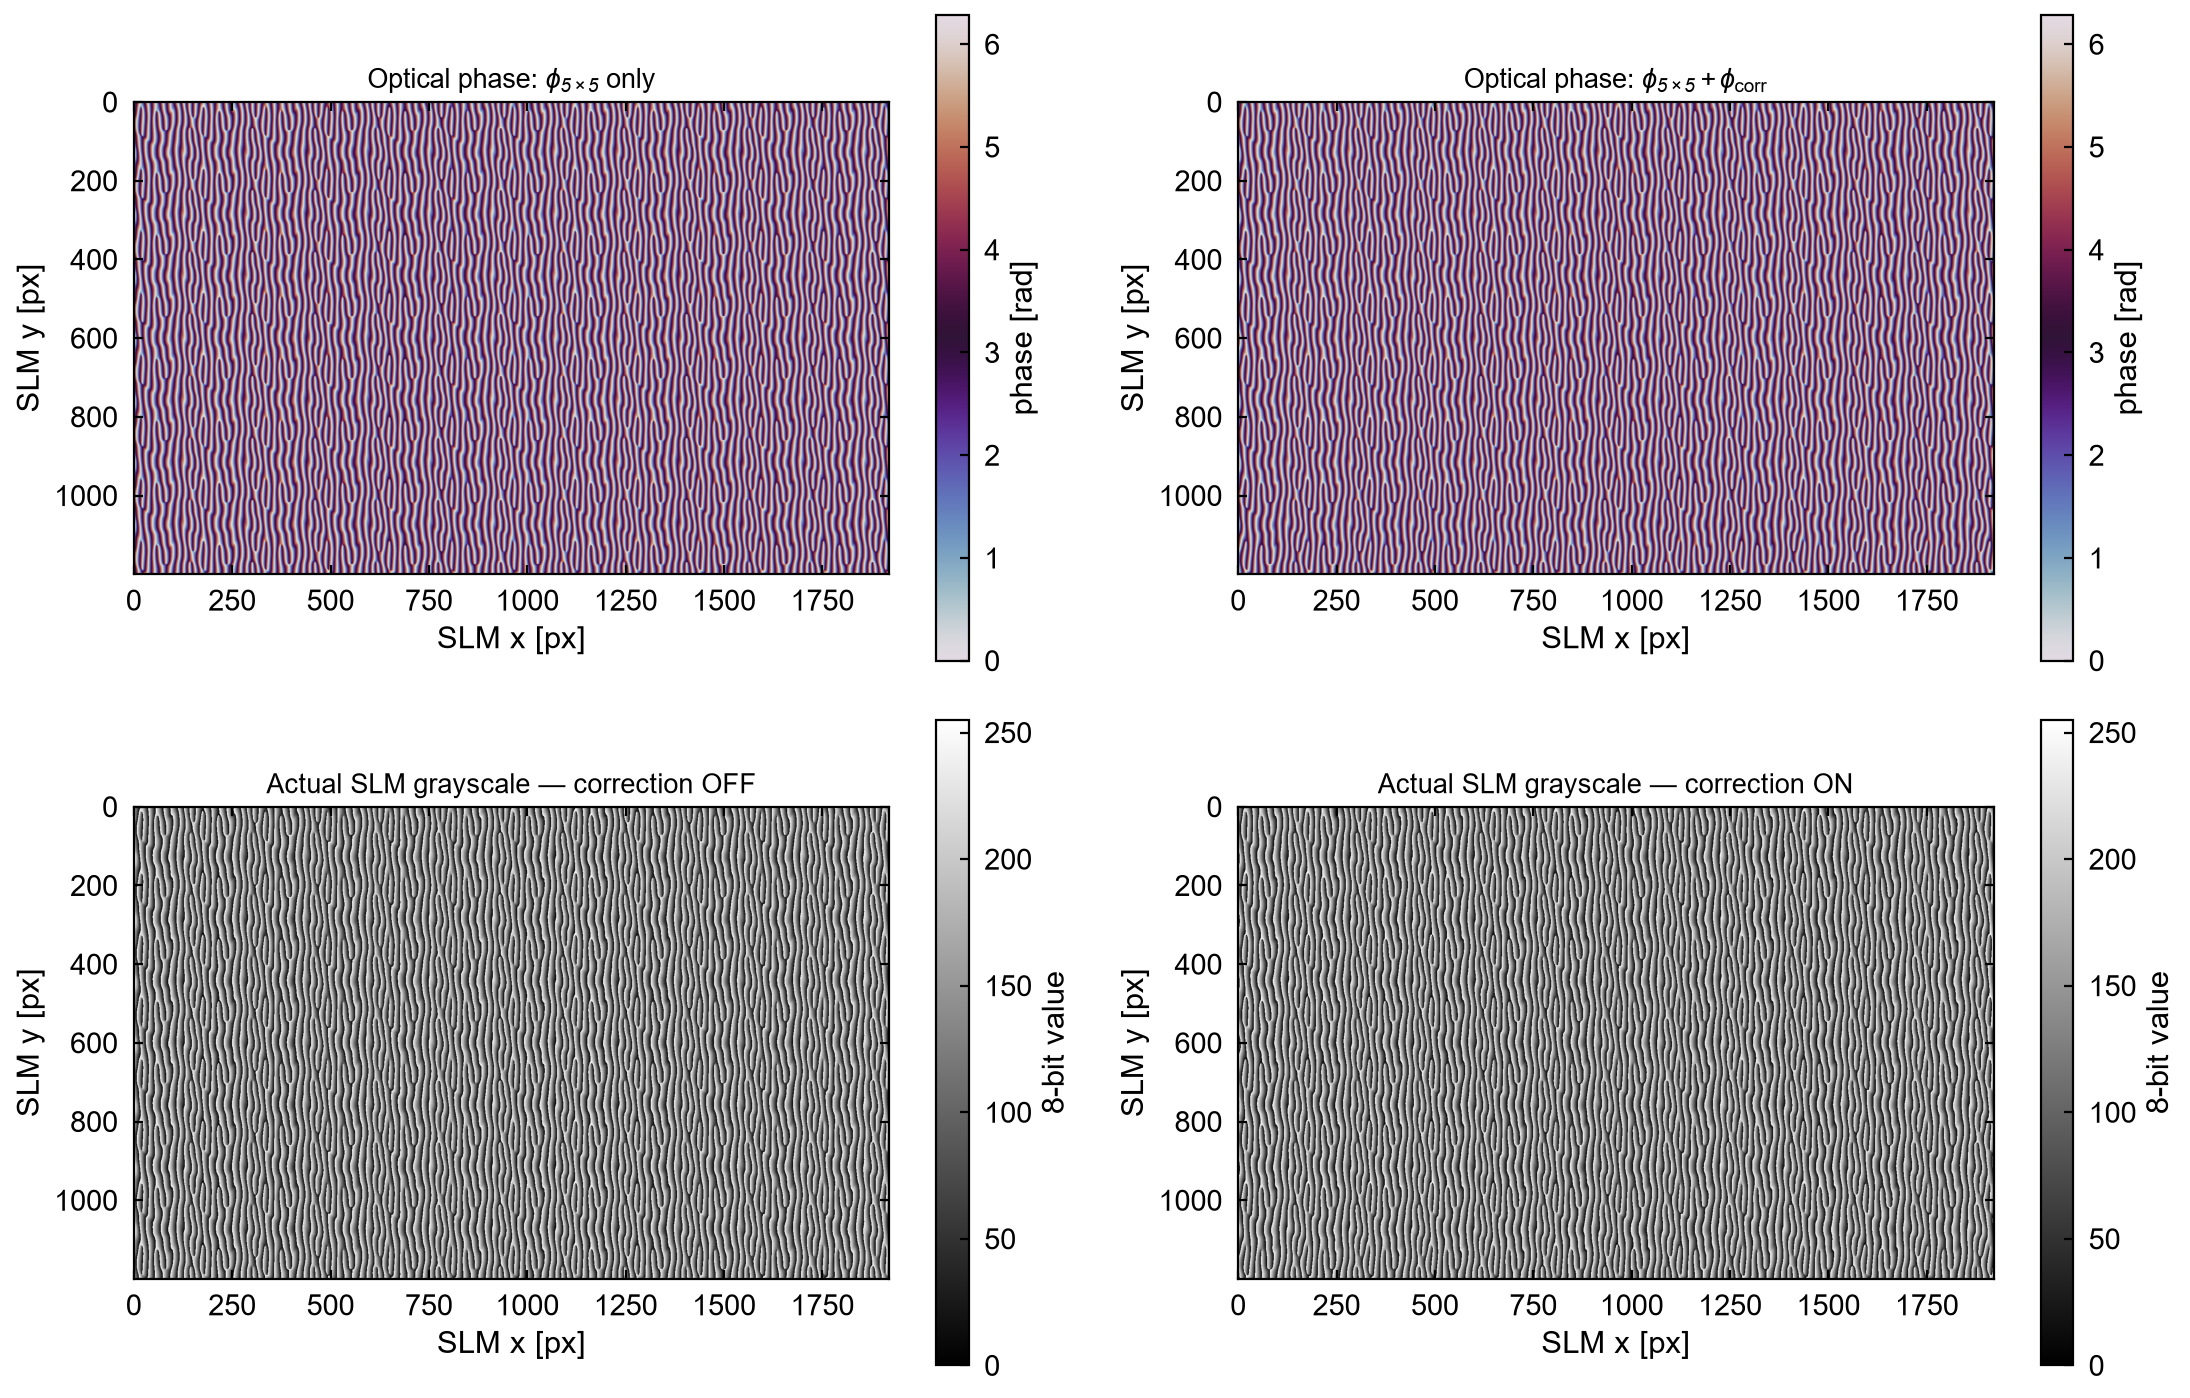

In [8]:
# ============================================================
# CELL 7 — Visualize what changes on the SLM
#
# Compare:
#   1. Optical phase, correction OFF
#   2. Optical phase, correction ON
#   3. Actual 8-bit hardware pattern sent to SLM
# ============================================================

# ------------------------------------------------------------
# A. Construct the two optical phase maps conceptually
# ------------------------------------------------------------

phi_off = np.mod(
    phase_5x5,
    2 * np.pi
)

phi_on = np.mod(
    phase_5x5 + wavefront_phase,
    2 * np.pi
)


# ------------------------------------------------------------
# B. Actually write OFF and save the hardware grayscale
# ------------------------------------------------------------

slm.set_phase(
    phase_5x5,
    phase_correct=False,
    settle=True
)

display_off = slm.display.copy()


# ------------------------------------------------------------
# C. Actually write ON and save the hardware grayscale
# ------------------------------------------------------------

slm.set_phase(
    phase_5x5,
    phase_correct=True,
    settle=True
)

display_on = slm.display.copy()


# ------------------------------------------------------------
# D. Sanity checks
# ------------------------------------------------------------

print("Optical phase OFF range:")
print(phi_off.min(), phi_off.max())

print("\nOptical phase ON range:")
print(phi_on.min(), phi_on.max())

print("\nHardware display dtype:")
print(display_on.dtype)

print("\nHardware grayscale OFF range:")
print(display_off.min(), display_off.max())

print("\nHardware grayscale ON range:")
print(display_on.min(), display_on.max())

print("\nNumber of hardware pixels changed:")
print(np.sum(display_off != display_on))

print(
    "Fraction of SLM pixels changed:",
    np.mean(display_off != display_on)
)


# ------------------------------------------------------------
# E. Plot
# ------------------------------------------------------------

fig, axs = plt.subplots(
    2, 2,
    figsize=(14, 9)
)

# Optical phase OFF
im0 = axs[0,0].imshow(
    phi_off,
    cmap="twilight",
    vmin=0,
    vmax=2*np.pi,
    origin="upper"
)

axs[0,0].set_title(
    r"Optical phase: $\phi_{5\times5}$ only"
)

plt.colorbar(
    im0,
    ax=axs[0,0],
    label="phase [rad]"
)


# Optical phase ON
im1 = axs[0,1].imshow(
    phi_on,
    cmap="twilight",
    vmin=0,
    vmax=2*np.pi,
    origin="upper"
)

axs[0,1].set_title(
    r"Optical phase: $\phi_{5\times5}+\phi_{\rm corr}$"
)

plt.colorbar(
    im1,
    ax=axs[0,1],
    label="phase [rad]"
)


# Hardware grayscale OFF
im2 = axs[1,0].imshow(
    display_off,
    cmap="gray",
    vmin=0,
    vmax=255,
    origin="upper"
)

axs[1,0].set_title(
    "Actual SLM grayscale — correction OFF"
)

plt.colorbar(
    im2,
    ax=axs[1,0],
    label="8-bit value"
)


# Hardware grayscale ON
im3 = axs[1,1].imshow(
    display_on,
    cmap="gray",
    vmin=0,
    vmax=255,
    origin="upper"
)

axs[1,1].set_title(
    "Actual SLM grayscale — correction ON"
)

plt.colorbar(
    im3,
    ax=axs[1,1],
    label="8-bit value"
)


for ax in axs.ravel():
    ax.set_xlabel("SLM x [px]")
    ax.set_ylabel("SLM y [px]")

plt.tight_layout()
plt.show()

phi_diff shape: (1200, 1920)
min [rad]: -3.1415906913639486
max [rad]: 3.1415913039301078
mean [rad]: 0.6530328540589583
std  [rad]: 1.7213156210731761


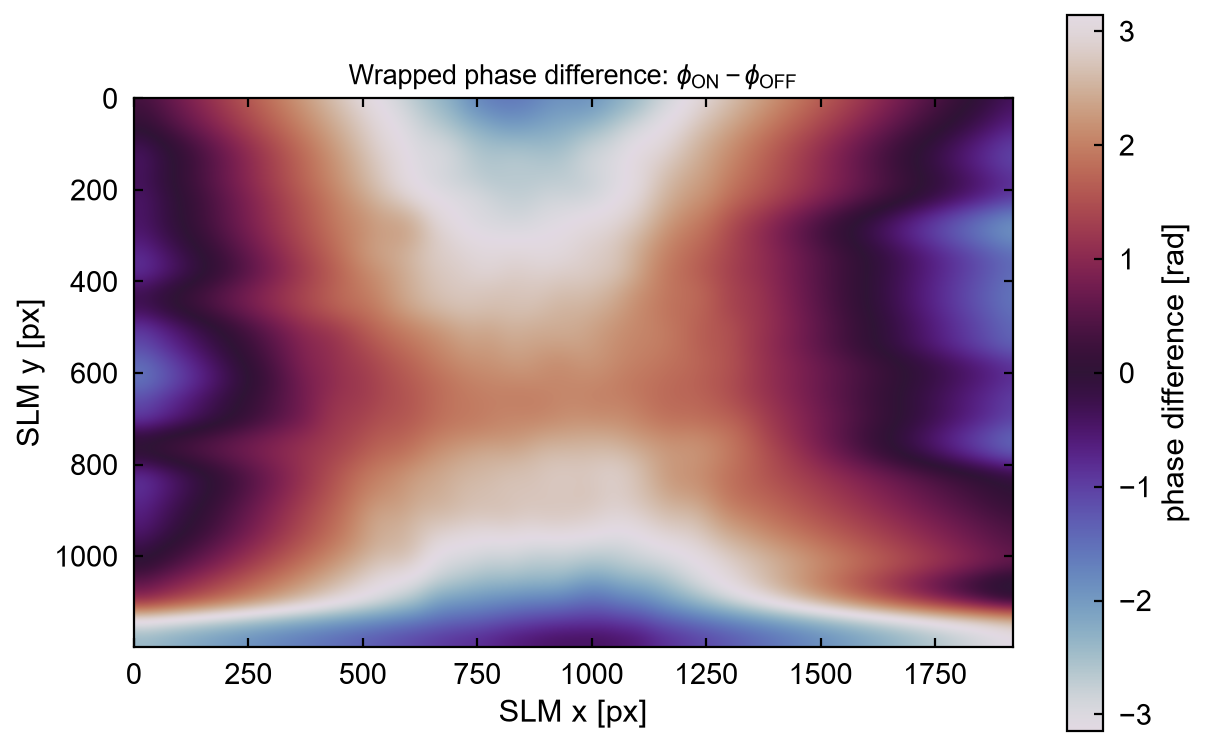

In [9]:
# ============================================================
# CELL 8 — Subtract OFF and ON optical phases
# ============================================================

# phi_off and phi_on already exist from previous cell:
# phi_off = mod(phase_5x5, 2pi)
# phi_on  = mod(phase_5x5 + wavefront_phase, 2pi)

# Wrapped phase difference in [-pi, pi]
phi_diff = np.angle(np.exp(1j * (phi_on - phi_off)))

print("phi_diff shape:", phi_diff.shape)
print("min [rad]:", np.min(phi_diff))
print("max [rad]:", np.max(phi_diff))
print("mean [rad]:", np.mean(phi_diff))
print("std  [rad]:", np.std(phi_diff))

plt.figure(figsize=(8, 5))
im = plt.imshow(
    phi_diff,
    cmap="twilight",
    origin="upper",
    vmin=-np.pi,
    vmax=np.pi
)
plt.title(r"Wrapped phase difference: $\phi_{\rm ON}-\phi_{\rm OFF}$")
plt.xlabel("SLM x [px]")
plt.ylabel("SLM y [px]")
plt.colorbar(im, label="phase difference [rad]")
plt.tight_layout()
plt.show()

Residual relative to stored correction
min [rad]: -8.881784197001252e-16
max [rad]: 1.3322676295501878e-15
RMS [rad]: 3.191286584494833e-16


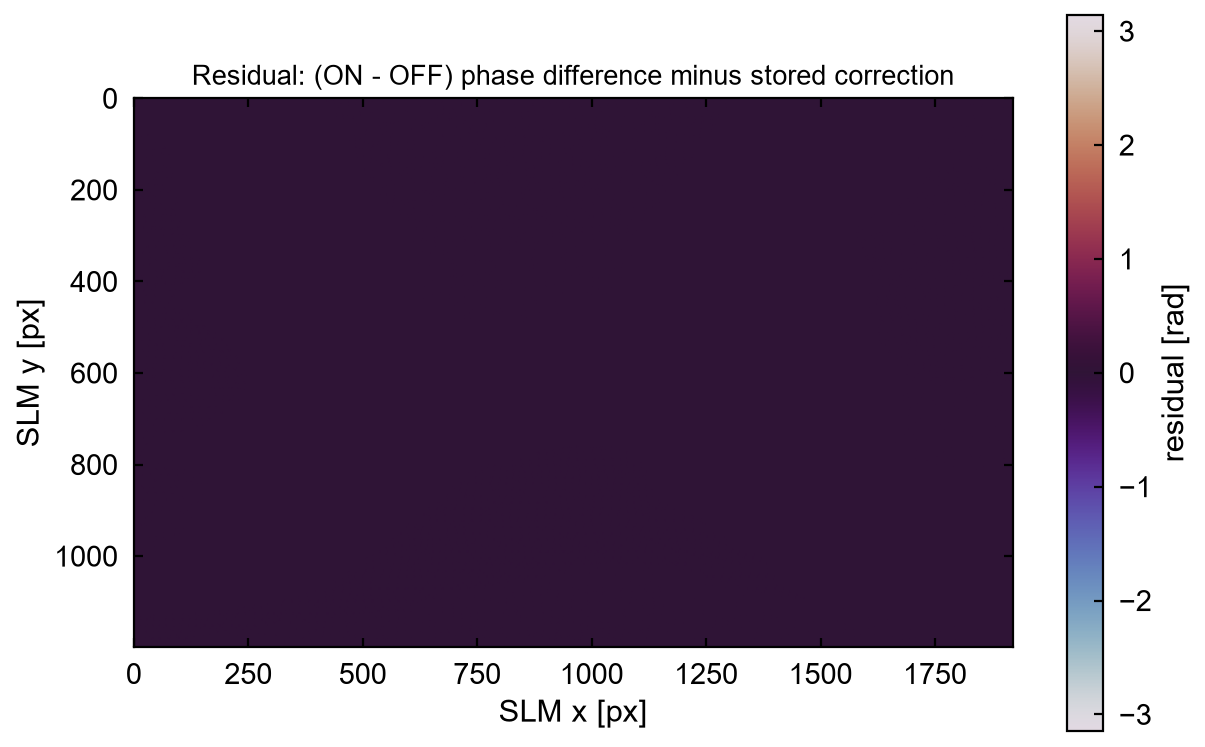

In [10]:
# Wrapped difference between measured subtraction and stored correction
corr_wrapped = np.angle(np.exp(1j * wavefront_phase))
residual = np.angle(np.exp(1j * (phi_diff - corr_wrapped)))

print("Residual relative to stored correction")
print("min [rad]:", np.min(residual))
print("max [rad]:", np.max(residual))
print("RMS [rad]:", np.sqrt(np.mean(residual**2)))

plt.figure(figsize=(8, 5))
im = plt.imshow(
    residual,
    cmap="twilight",
    origin="upper",
    vmin=-np.pi,
    vmax=np.pi
)
plt.title("Residual: (ON - OFF) phase difference minus stored correction")
plt.xlabel("SLM x [px]")
plt.ylabel("SLM y [px]")
plt.colorbar(im, label="residual [rad]")
plt.tight_layout()
plt.show()

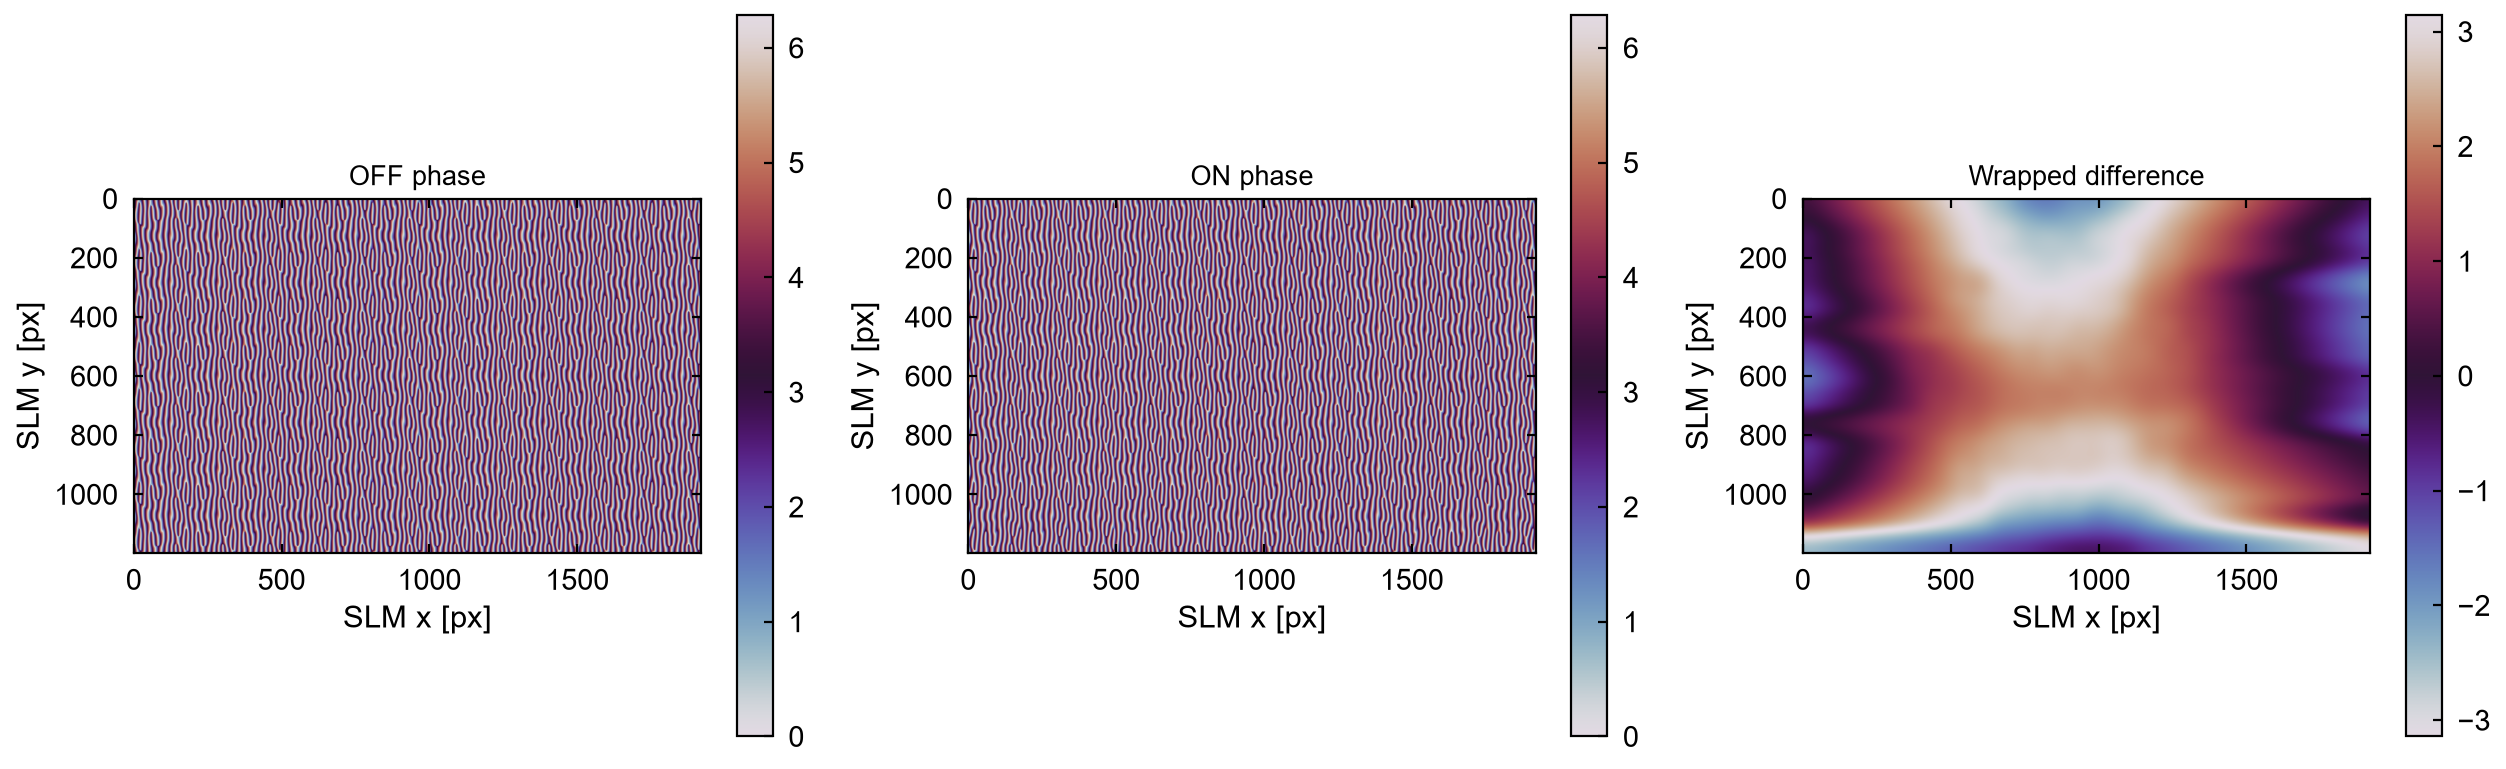

In [11]:
fig, axs = plt.subplots(1, 3, figsize=(16, 5))

im0 = axs[0].imshow(phi_off, cmap="twilight", vmin=0, vmax=2*np.pi)
axs[0].set_title("OFF phase")
plt.colorbar(im0, ax=axs[0])

im1 = axs[1].imshow(phi_on, cmap="twilight", vmin=0, vmax=2*np.pi)
axs[1].set_title("ON phase")
plt.colorbar(im1, ax=axs[1])

im2 = axs[2].imshow(phi_diff, cmap="twilight", vmin=-np.pi, vmax=np.pi)
axs[2].set_title("Wrapped difference")
plt.colorbar(im2, ax=axs[2])

for ax in axs:
    ax.set_xlabel("SLM x [px]")
    ax.set_ylabel("SLM y [px]")

plt.tight_layout()
plt.show()

RMS residual [rad]: 3.191286584494833e-16
Max |residual| [rad]: 1.3322676295501878e-15


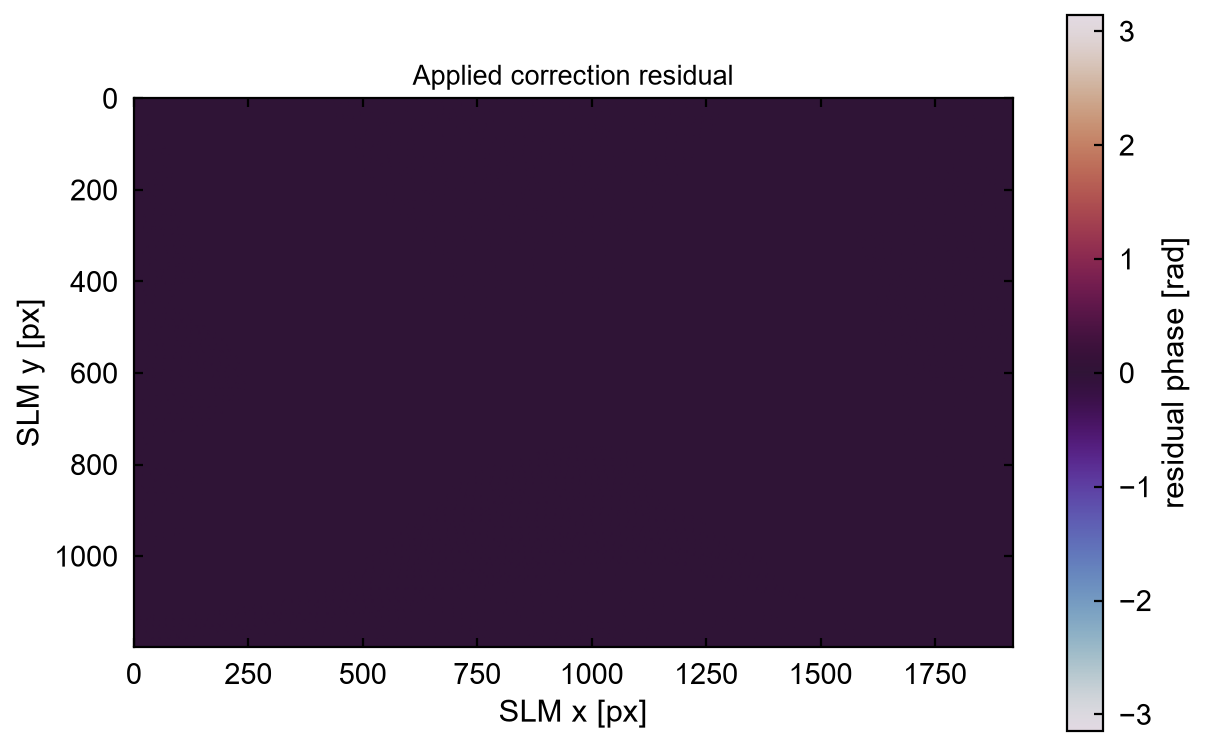

In [12]:
# Wrapped version of stored correction
corr_wrapped = np.angle(
    np.exp(1j * wavefront_phase)
)

# Difference between what we inferred was applied
# and what was actually stored
residual = np.angle(
    np.exp(1j * (phi_diff - corr_wrapped))
)

print("RMS residual [rad]:",
      np.sqrt(np.mean(residual**2)))

print("Max |residual| [rad]:",
      np.max(np.abs(residual)))

plt.figure(figsize=(8,5))

plt.imshow(
    residual,
    cmap="twilight",
    origin="upper",
    vmin=-np.pi,
    vmax=np.pi
)

plt.colorbar(label="residual phase [rad]")
plt.xlabel("SLM x [px]")
plt.ylabel("SLM y [px]")
plt.title("Applied correction residual")

plt.tight_layout()
plt.show()

## Fourier calibration with the new wavefront correction

Exposure [us]: 497.181
Full-frame max: 255
Brightest pixel [y,x]: (np.int64(1806), np.int64(4356))


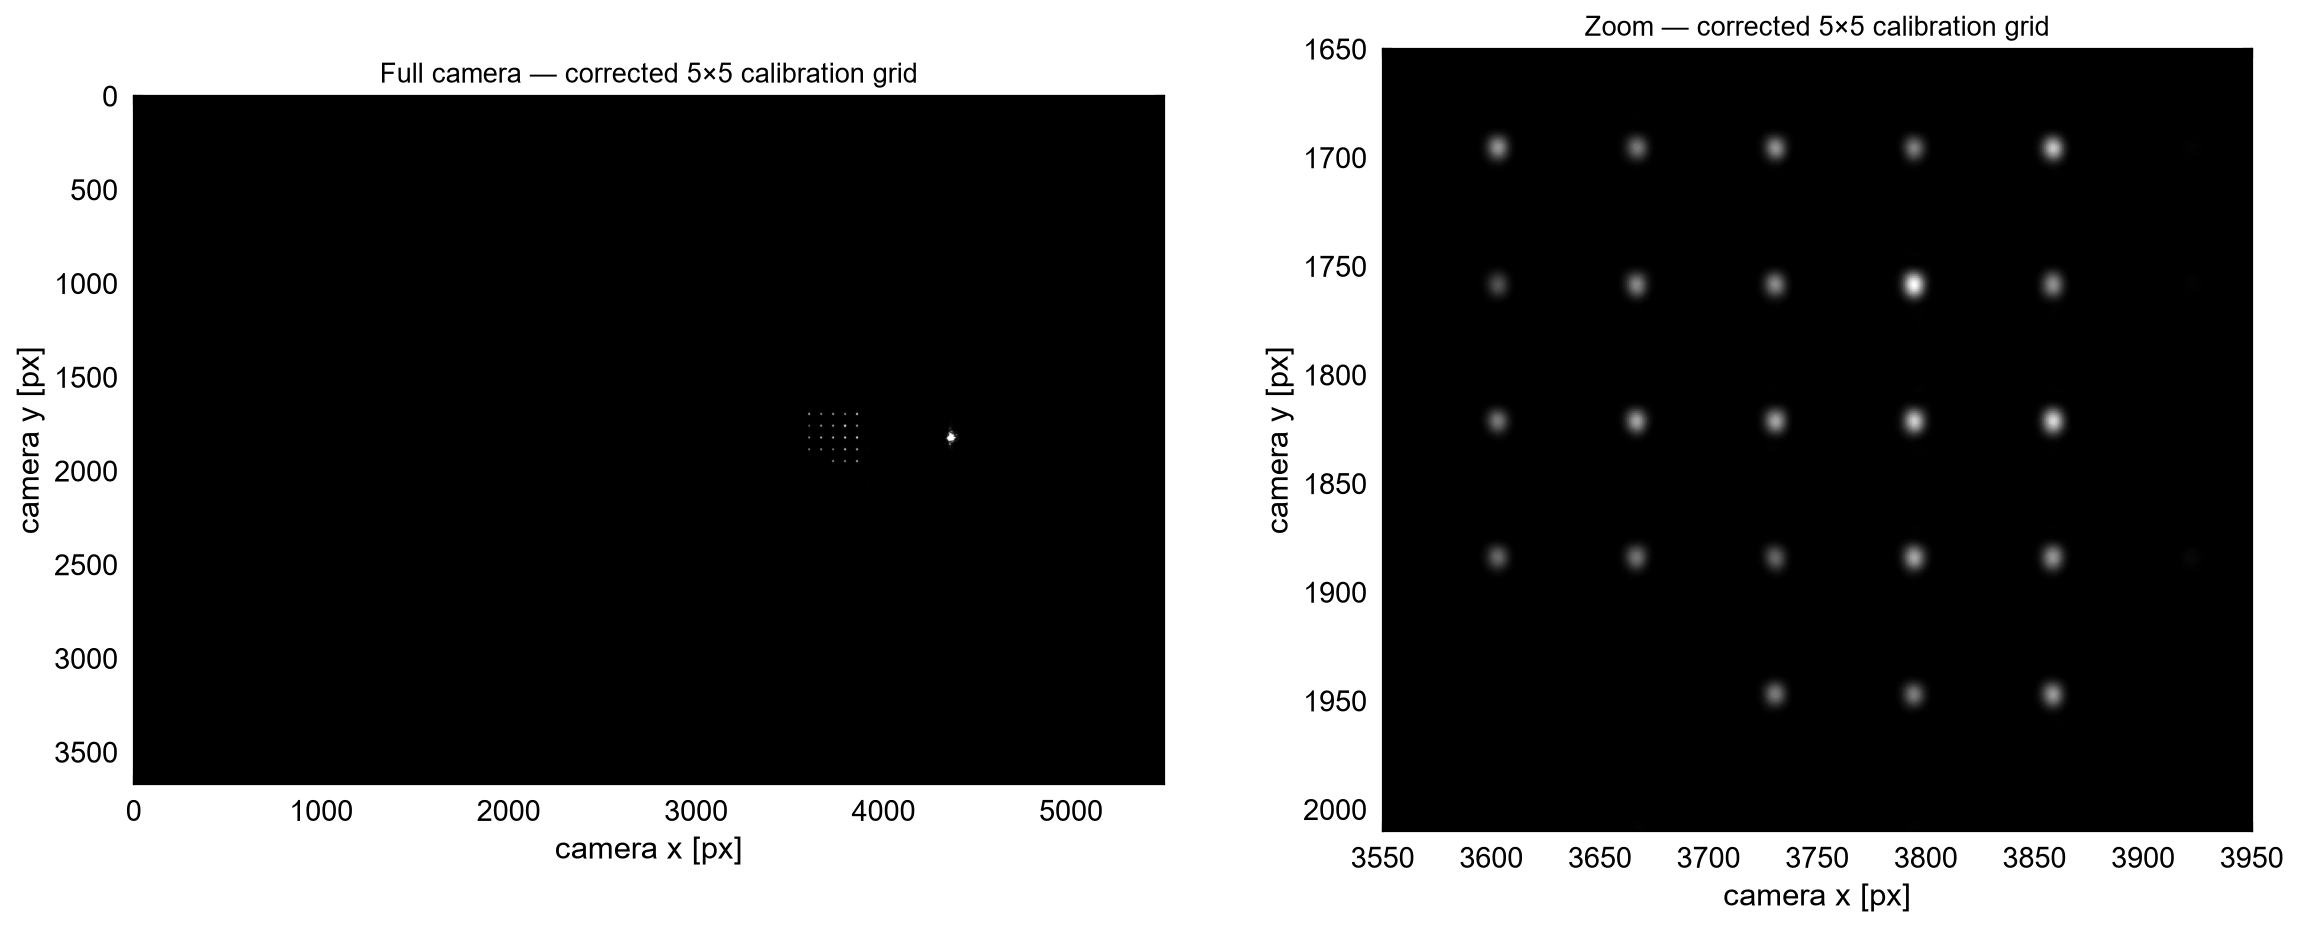

In [13]:
# ============================================================
# FOURIER CALIBRATION — STEP 1
# Display known 5×5 grid WITH wavefront correction
# and acquire the full camera frame
# ============================================================

# Good exposure from our previous 5×5 test
cam.set_exposure(500e-6)

# Display the SAME known 5×5 hologram,
# explicitly with wavefront correction ON
slm.set_phase(
    phase_5x5,
    phase_correct=True,
    settle=True
)

cam.flush()
img_fourier_cal = cam.get_image()

print("Exposure [us]:", cam.exposure_s * 1e6)
print("Full-frame max:", img_fourier_cal.max())

max_yx = np.unravel_index(
    np.argmax(img_fourier_cal),
    img_fourier_cal.shape
)

print("Brightest pixel [y,x]:", max_yx)


# ------------------------------------------------------------
# Show full sensor + zoom around calibration grid
# ------------------------------------------------------------

fig, axs = plt.subplots(1, 2, figsize=(15, 6))

axs[0].imshow(
    img_fourier_cal,
    cmap="gray",
    origin="upper",
    vmin=0,
    vmax=100
)
axs[0].set_title("Full camera — corrected 5×5 calibration grid")
axs[0].set_xlabel("camera x [px]")
axs[0].set_ylabel("camera y [px]")


axs[1].imshow(
    img_fourier_cal,
    cmap="gray",
    origin="upper",
    vmin=0,
    vmax=img_fourier_cal[1650:2010, 3550:3950].max()
)
axs[1].set_xlim(3550, 3950)
axs[1].set_ylim(2010, 1650)
axs[1].set_title("Zoom — corrected 5×5 calibration grid")
axs[1].set_xlabel("camera x [px]")
axs[1].set_ylabel("camera y [px]")

plt.tight_layout()
plt.show()

In [14]:
# ============================================================
# FOURIER CALIBRATION — STEP 2
# Inspect blob_array_detect() before using it
# ============================================================

import inspect
from slmsuite.holography import analysis

print("Signature:")
print(inspect.signature(analysis.blob_array_detect))

print("\nDocstring:")
print(inspect.getdoc(analysis.blob_array_detect))

Signature:
(img, size, orientation=None, orientation_check=True, dft_threshold=100, dft_padding=0, k=8, tol=0.1, plot=False)

Docstring:
Detect an array of spots and return the orientation as an affine transformation.
Primarily used for calibration.

For a rectangular array of spots imaged in ``img``,
find the variables :math:`\vec{M}` and :math:`\vec{b}` for the  affine transformation

.. math:: \vec{y} = M \cdot \vec{x} + \vec{b}

which converts spot indices :math:`\vec{x}` into camera pixel indices :math:`\vec{y}`.

Parameters
----------
img : numpy.ndarray
    The image in question.
size : (int, int) OR int
    The size of the rectangular array in number of spots ``(Nx, Ny)``.
    If a single ``int`` size is given, then assume ``(N, N)``.
orientation : dict or None
    Guess array orientation (same format as the returned) from previous known results.
    If ``None`` (the default), orientation is estimated from looking for peaks in the
    Fourier transform of the image.
orientation

Bright zero order [x,y]:
4356 1806


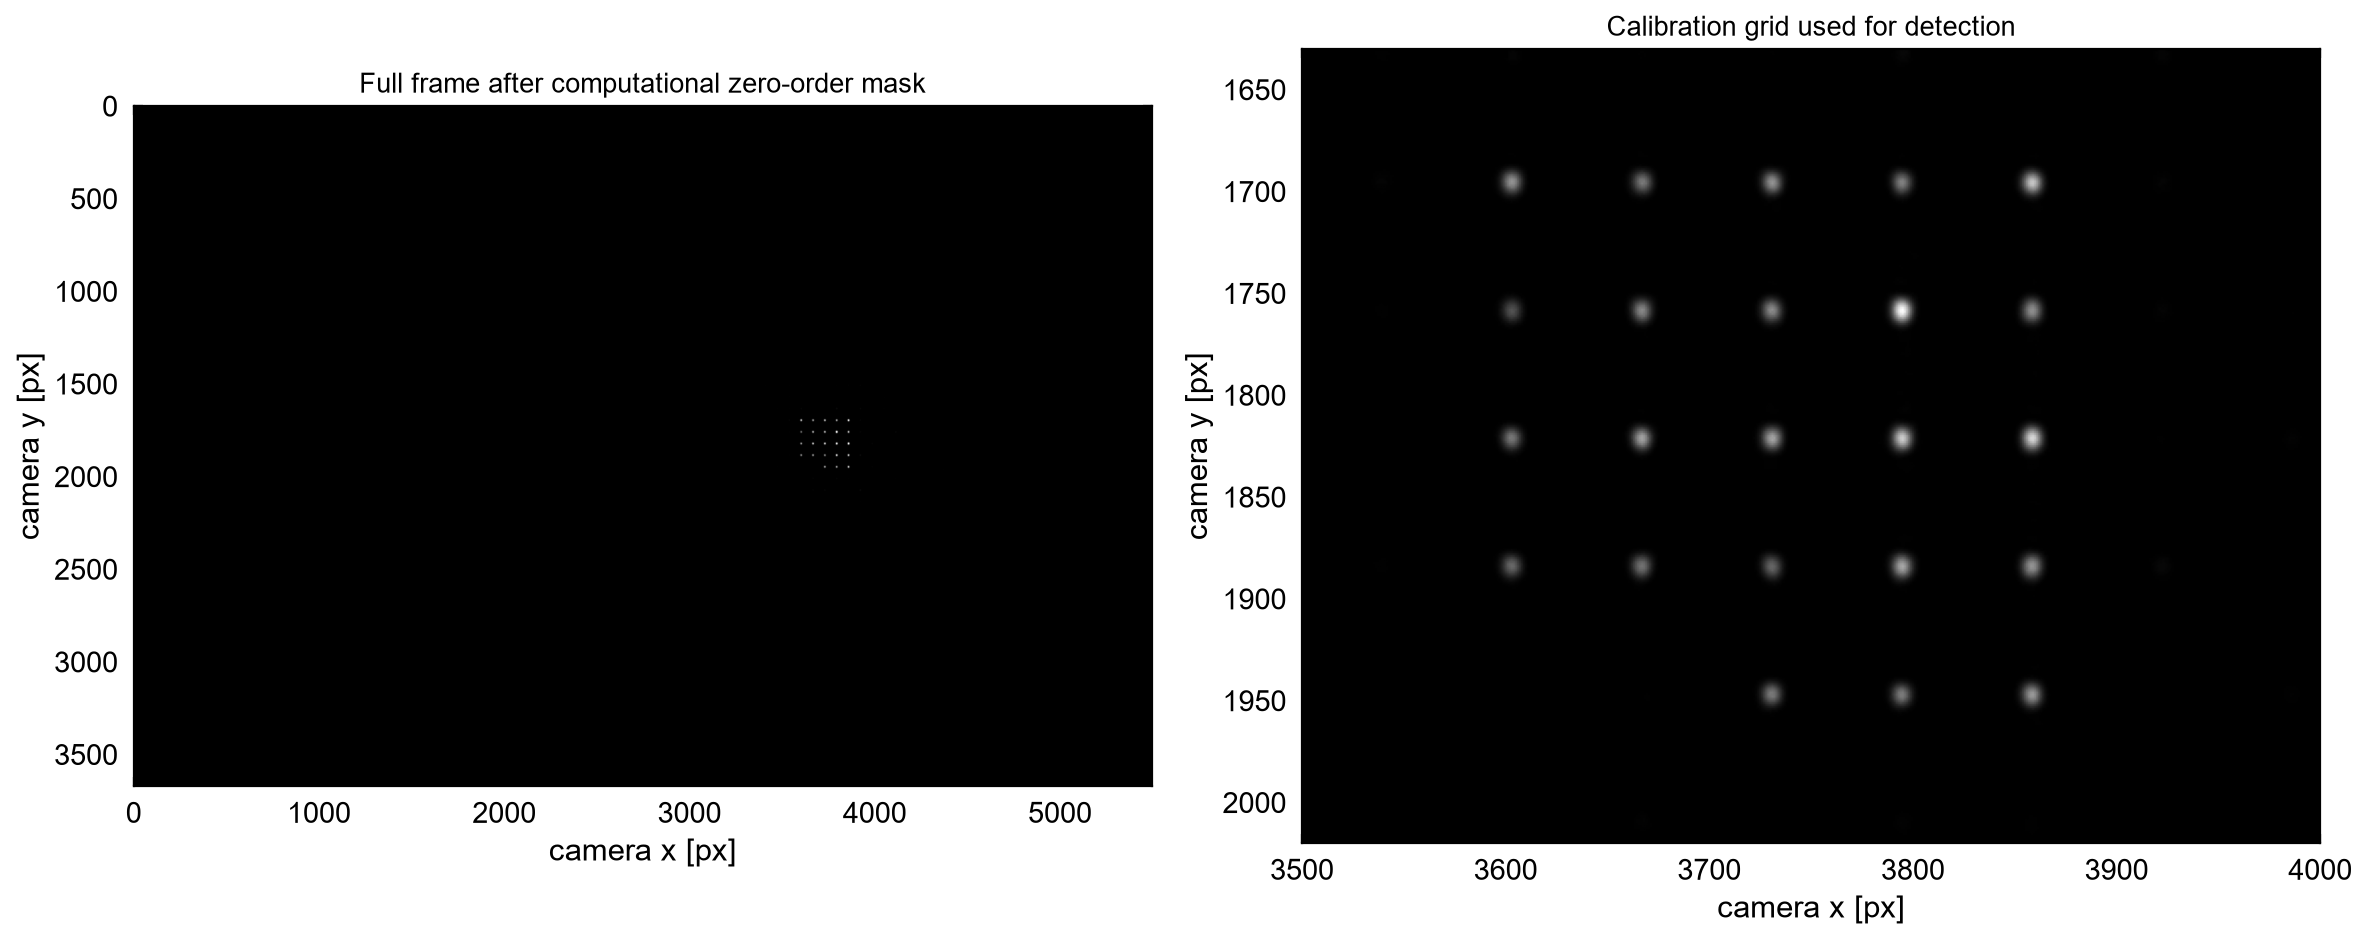

c:\Users\admin\AppData\Local\Python\pythoncore-3.12-64\Lib\site-packages\slmsuite\holography\analysis\__init__.py:2261: UserWarning: The fitted spot array approaches or exceeds the camera FOV; calibration results may be improperly centered as a result.
  warnings.warn(


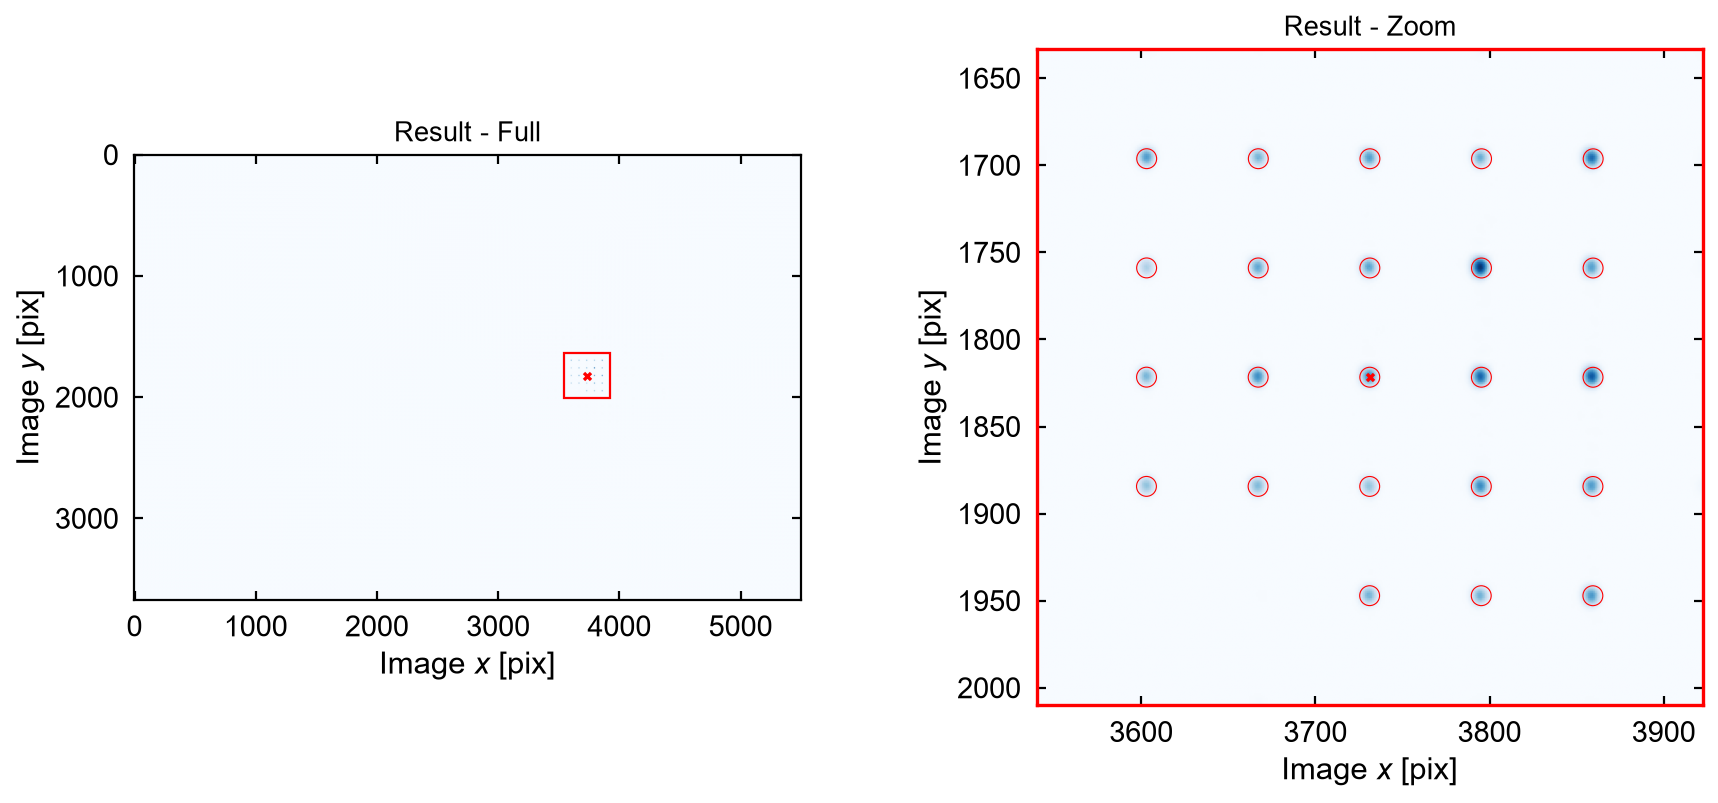


Detected orientation dictionary:
{'M': array([[-6.40900997e+01, -4.30302777e-02],
       [-1.65182341e-02,  6.27188452e+01]]), 'b': array([[3731.2180387 ],
       [1821.68919653]])}

M_blob:
[[-6.40900997e+01 -4.30302777e-02]
 [-1.65182341e-02  6.27188452e+01]]

b_blob:
[[3731.2180387 ]
 [1821.68919653]]


In [15]:
# ============================================================
# FOURIER CALIBRATION — STEP 2
# Mask bright zero order and detect the corrected 5×5 lattice
# ============================================================

from slmsuite.holography import analysis

# Work on a COPY. Do not change our original camera image.
img_detect = img_fourier_cal.copy()


# ------------------------------------------------------------
# 1. Locate bright zero order
# ------------------------------------------------------------

zero_y, zero_x = np.unravel_index(
    np.argmax(img_detect),
    img_detect.shape
)

print("Bright zero order [x,y]:")
print(zero_x, zero_y)


# ------------------------------------------------------------
# 2. Mask a circular region around zero order
#
# This changes intensities only.
# The camera array dimensions and coordinate system stay intact.
# ------------------------------------------------------------

MASK_RADIUS = 120   # camera pixels

Y, X = np.indices(img_detect.shape)

zero_mask = (
    (X - zero_x)**2 +
    (Y - zero_y)**2
) <= MASK_RADIUS**2

img_detect[zero_mask] = 0


# ------------------------------------------------------------
# 3. Visual sanity check
# ------------------------------------------------------------

fig, axs = plt.subplots(1, 2, figsize=(15, 6))

axs[0].imshow(
    img_detect,
    cmap="gray",
    origin="upper",
    vmin=0,
    vmax=100
)
axs[0].set_title("Full frame after computational zero-order mask")

axs[1].imshow(
    img_detect,
    cmap="gray",
    origin="upper",
    vmin=0,
    vmax=img_detect[1650:2010, 3550:3950].max()
)
axs[1].set_xlim(3500, 4000)
axs[1].set_ylim(2020, 1630)
axs[1].set_title("Calibration grid used for detection")

for ax in axs:
    ax.set_xlabel("camera x [px]")
    ax.set_ylabel("camera y [px]")

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 4. Detect the 5×5 lattice
# ------------------------------------------------------------

orientation_post = analysis.blob_array_detect(
    img_detect,
    size=(5, 5),
    orientation=None,
    orientation_check=True,
    plot=True,
)


print("\nDetected orientation dictionary:")
print(orientation_post)

print("\nM_blob:")
print(orientation_post["M"])

print("\nb_blob:")
print(orientation_post["b"])

In [16]:
# ============================================================
# FOURIER CALIBRATION — STEP 3
# Convert blob-grid coordinates -> physical kxy calibration
# Nothing is installed yet
# ============================================================

# Known geometry of the calibration hologram
ARRAY_PITCH_KNM = np.array([13.0, 13.0])
ARRAY_CENTER_KNM = np.array([128.0, 0.0])

# Computational hologram size.
# SpotHologram is padded to 2048×2048 in our setup.
print("Hologram computational shape:", holo_5x5.shape)
print("SLM normalized pitch:", slm.pitch)

NY_FFT, NX_FFT = holo_5x5.shape

# ------------------------------------------------------------
# 1. Conversion: one knm pixel -> kxy
# ------------------------------------------------------------

kxy_per_knm = np.array([
    1.0 / (NX_FFT * slm.pitch[0]),
    1.0 / (NY_FFT * slm.pitch[1]),
])

print("\nkxy per knm pixel:")
print(kxy_per_knm)


# ------------------------------------------------------------
# 2. Physical kxy position of calibration-array center
#    (= our 16-pixel carrier)
# ------------------------------------------------------------

array_center_kxy = ARRAY_CENTER_KNM * kxy_per_knm

print("\nCalibration-array center kxy:")
print(array_center_kxy)


# ------------------------------------------------------------
# 3. kxy displacement corresponding to ONE blob-grid index
#
# Neighboring calibration spots differ by 13 knm.
# ------------------------------------------------------------

delta_kxy = ARRAY_PITCH_KNM * kxy_per_knm

print("\nkxy displacement per calibration-grid step:")
print(delta_kxy)


# ------------------------------------------------------------
# 4. Convert M_blob from:
#
#       camera pixels / grid index
#
#    into:
#
#       camera pixels / kxy
#
# Each column gets divided by the relevant kxy grid spacing.
# ------------------------------------------------------------

M_blob = np.asarray(orientation_post["M"], dtype=float)
b_carrier = np.asarray(orientation_post["b"], dtype=float)

M_fourier_post = (
    M_blob @ np.diag(1.0 / delta_kxy)
)

print("\nNew Fourier M:")
print(M_fourier_post)


# ------------------------------------------------------------
# 5. Convert representation
#
# blob fit naturally says:
#
# ij = M @ (kxy - array_center_kxy) + b_carrier
#
# We prefer slmsuite's equivalent a=(0,0) representation:
#
# ij = M @ kxy + b_zero
#
# therefore:
#
# b_zero = b_carrier - M @ array_center_kxy
# ------------------------------------------------------------

b_zero_post = (
    b_carrier
    - M_fourier_post @ array_center_kxy.reshape(2, 1)
)

print("\nEquivalent zero-kxy camera intercept:")
print(b_zero_post)


# ------------------------------------------------------------
# 6. Sanity checks
# ------------------------------------------------------------

ij_zero_pred = b_zero_post.ravel()

ij_carrier_pred = (
    M_fourier_post @ array_center_kxy.reshape(2,1)
    + b_zero_post
).ravel()

print("\nPredicted zero-order coordinate [x,y]:")
print(ij_zero_pred)

print("\nPredicted 16-pixel carrier coordinate [x,y]:")
print(ij_carrier_pred)

print("\nMeasured blob-array center [x,y]:")
print(b_carrier.ravel())

print("\nCarrier reconstruction error [px]:")
print(ij_carrier_pred - b_carrier.ravel())

Hologram computational shape: (np.int64(2048), np.int64(2048))
SLM normalized pitch: [10.53602002 10.53602002]

kxy per knm pixel:
[4.63439941e-05 4.63439941e-05]

Calibration-array center kxy:
[0.00593203 0.        ]

kxy displacement per calibration-grid step:
[0.00060247 0.00060247]

New Fourier M:
[[-1.06378567e+05 -7.14228763e+01]
 [-2.74174338e+01  1.04102520e+05]]

Equivalent zero-kxy camera intercept:
[[4362.25902077]
 [1821.8518376 ]]

Predicted zero-order coordinate [x,y]:
[4362.25902077 1821.8518376 ]

Predicted 16-pixel carrier coordinate [x,y]:
[3731.2180387  1821.68919653]

Measured blob-array center [x,y]:
[3731.2180387  1821.68919653]

Carrier reconstruction error [px]:
[0. 0.]


In [17]:
# ============================================================
# FOURIER CALIBRATION — STEP 4
# Install the post-wavefront Fourier calibration
# ============================================================

fs.fourier_calibrate_analytic(
    M_fourier_post,
    b_zero_post
)

print("Stored Fourier calibration keys:")
print(fs.calibrations["fourier"].keys())

print("\nStored M:")
print(fs.calibrations["fourier"]["M"])

print("\nStored a:")
print(fs.calibrations["fourier"]["a"])

print("\nStored b:")
print(fs.calibrations["fourier"]["b"])


# ------------------------------------------------------------
# Verify zero order and 16-pixel carrier using slmsuite itself
# ------------------------------------------------------------

kxy_zero = np.array([0.0, 0.0])

kxy_carrier = np.array([
    0.00593203125,
    0.0
])

ij_zero = fs.kxyslm_to_ijcam(kxy_zero)
ij_carrier = fs.kxyslm_to_ijcam(kxy_carrier)

print("\nZERO ORDER")
print("kxy =", kxy_zero)
print("ij  =", ij_zero)

print("\n16-PIXEL CARRIER")
print("kxy =", kxy_carrier)
print("ij  =", ij_carrier)

print("\nCarrier displacement:")
print(ij_carrier - ij_zero)

Stored Fourier calibration keys:
dict_keys(['M', 'b', 'a', '__version__', '__time__', '__timestamp__', '__meta__'])

Stored M:
[[-1.06378567e+05 -7.14228763e+01]
 [-2.74174338e+01  1.04102520e+05]]

Stored a:
[[0]
 [0]]

Stored b:
[[4362.25902077]
 [1821.8518376 ]]

ZERO ORDER
kxy = [0. 0.]
ij  = [[4362.25902077]
 [1821.8518376 ]]

16-PIXEL CARRIER
kxy = [0.00593203 0.        ]
ij  = [[3731.2180387 ]
 [1821.68919653]]

Carrier displacement:
[[-6.31040982e+02]
 [-1.62641074e-01]]


In [18]:
# ============================================================
# NEXT CELL — Find calibration save API
# Nothing is modified
# ============================================================

import inspect

save_methods = [
    name for name in dir(fs)
    if "save" in name.lower()
]

print("Possible save methods:")
print(save_methods)

for name in save_methods:
    func = getattr(fs, name)

    if callable(func):
        print("\n" + "="*60)
        print(name)

        try:
            print(inspect.signature(func))
        except Exception:
            pass

        doc = inspect.getdoc(func)

        if doc is not None:
            print(doc[:1500])

Possible save methods:
['save', 'save_calibration']

save
(path='.', name=None, **kwargs)
Saves the dictionary returned from :meth:`pickle()` to a file like ``"path/name_id.h5"``.

Parameters
----------
path : str
    Path to directory to save in. Default is current directory.
name : str OR None
    Name of the save file. If ``None``, will use :attr:`name` + ``'-pickle'``.
**kwargs
    Passed to :meth:`pickle()` to customize how and what data is saved.

Returns
-------
str
    The file path that the pickled data was saved to.

save_calibration
(calibration_type, path='.', name=None)
to a file like ``"path/name_id.h5"``.

Parameters
----------
calibration_type : str
    The type of calibration to save. See :attr:`calibrations` for supported
    options. Works for any key of :attr:`calibrations`.
path : str
    Path to directory to save in. Default is current directory.
name : str OR None
    Name of the save file. If ``None``, will use :meth:`name_calibration`.

Returns
-------
str
    

In [19]:
# ============================================================
# SAVE POST-WAVEFRONT FOURIER CALIBRATION
# ============================================================

FOURIER_SAVE_DIR = WAVEFRONT_PHASE_PATH.parent

saved_fourier_path = fs.save_calibration(
    "fourier",
    path=str(FOURIER_SAVE_DIR),
    name="YDFC_fourier_post_wavefront"
)

print("Saved post-wavefront Fourier calibration to:")
print(saved_fourier_path)

print("\nCurrent Fourier calibration:")
print("M =")
print(fs.calibrations["fourier"]["M"])

print("\na =")
print(fs.calibrations["fourier"]["a"])

print("\nb =")
print(fs.calibrations["fourier"]["b"])

Saved post-wavefront Fourier calibration to:
C:\Users\admin\Desktop\Projects\SLM\SLM tests\Scripts\4f alignment scripts\YDFC_fourier_post_wavefront_00000.h5

Current Fourier calibration:
M =
[[-1.06378567e+05 -7.14228763e+01]
 [-2.74174338e+01  1.04102520e+05]]

a =
[[0]
 [0]]

b =
[[4362.25902077]
 [1821.8518376 ]]
